# Elastic Net HDB Resale Model Notebook

This notebook made to:

- show the output step by step
- clearly document how the Elastic Net model was tuned
- report both log-scale and back-transformed price metrics

**Expected file in the same folder:** `hdb_with_amenities_macro.csv`


## 1. Imports

I first import the libraries used for data handling, feature engineering, model fitting, and evaluation.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



## 2. Load data and match the OLS sample

This section reproduces the same sample restrictions used in the OLS specification, so the Elastic Net results are directly comparable.

The main cleaning choices are:

- drop rows with missing values
- drop duplicate rows
- create the target variable `log_resale_price_real`




In [3]:
df_raw = pd.read_csv("../../merged_data/[FINAL]hdb_with_amenities_macro_pre2026.csv")
print(f"Initial shape: {df_raw.shape}")



df = df_raw.dropna().copy()
print(f"After dropping nulls: {df.shape}")


n_before = len(df)
df = df.drop_duplicates().copy()
print(f"After dropping duplicates: {df.shape} (dropped {n_before - len(df)})")

df["log_resale_price_real"] = np.log(df["resale_price_real"])


df.head()

Initial shape: (134479, 37)
After dropping nulls: (134301, 37)
After dropping duplicates: (134211, 37) (dropped 90)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,dist_nearest_park_m,parks_1km,num_parks_1km,dist_nearest_sportsg_m,nearest_sportsg_name,dist_nearest_mall_m,nearest_mall_name,dist_nearest_healthcare_m,nearest_healthcare_name,log_resale_price_real
0,2021-01-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,64 years 01 month,...,703.5,GELENGGANG PARK|LEBAN PARK|BISHAN-ANG MO KIO P...,4,925.7,ActiveSG Gym@Ang Mo Kio Community Centre,1083.8,Broadway Plaza,1028.5,Ang Mo Kio Polyclinic,12.618536
1,2021-01-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,07 TO 09,45.0,Improved,1986,64 years 01 month,...,703.5,GELENGGANG PARK|LEBAN PARK|BISHAN-ANG MO KIO P...,4,925.7,ActiveSG Gym@Ang Mo Kio Community Centre,1083.8,Broadway Plaza,1028.5,Ang Mo Kio Polyclinic,12.682778
2,2021-01-01,ANG MO KIO,3 ROOM,331,ANG MO KIO AVE 1,04 TO 06,68.0,New Generation,1981,59 years,...,275.5,ANG MO KIO TOWN GARDEN EAST|BISHAN-ANG MO KIO ...,2,180.2,Ang Mo Kio Swimming Complex,858.7,Ang Mo Kio Hub,1471.1,Ang Mo Kio Polyclinic,12.827360
3,2021-01-01,ANG MO KIO,3 ROOM,534,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,58 years 02 months,...,580.2,ANG MO KIO TOWN GARDEN EAST,1,1296.5,Ang Mo Kio Swimming Complex,754.5,Jubilee Square,944.3,Ang Mo Kio Polyclinic,12.846408
4,2021-01-01,ANG MO KIO,3 ROOM,561,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1980,58 years 01 month,...,720.3,ANG MO KIO TOWN GARDEN EAST|TAVISTOCK AVE PK|H...,3,1217.7,Ang Mo Kio Swimming Complex,1011.5,myVillage,1416.3,Ang Mo Kio Polyclinic,12.846408


## 3. Stratified train-test split

To stay consistent with the OLS benchmark, the split is stratified by:

`town + flat_type + year`

Rows belonging to a `strat_key` that appears only once are removed first, because stratified splitting requires at least 2 observations in a stratum.


In [4]:
df["strat_key"] = (
    df["town"].astype(str) + "_" +
    df["flat_type"].astype(str) + "_" +
    df["year"].astype(str)
)

strat_counts = df["strat_key"].value_counts()
valid_keys = strat_counts[strat_counts >= 2].index
n_before = len(df)

df = df[df["strat_key"].isin(valid_keys)].copy()
print(f"Dropped {n_before - len(df)} rows with singleton strat_key combinations. Remaining: {len(df):,}")

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["strat_key"]
)

print(f"Train size: {len(train_df):,} | Test size: {len(test_df):,}")

Dropped 6 rows with singleton strat_key combinations. Remaining: 134,205
Train size: 107,364 | Test size: 26,841


## 4. Define features

### Continuous features
These are scaled using `StandardScaler` so that all variables are on a comparable scale before Elastic Net is fitted. This is important because Elastic Net penalizes coefficient sizes, and without scaling, variables with different numeric ranges would be penalized unfairly.

### Categorical features
These are one-hot encoded using `pd.get_dummies()`so they can be represented numerically in the regression model.

We also manually drop the same reference categories as in the OLS setup, so the design matrix is aligned with that interpretation.


In [5]:
continuous_features = [
    "remaining_lease_years",
    "nearest_train_dist_m",
    "dist_nearest_hawker_m",
    "dist_nearest_primary_m",
    "num_primary_1km",
    "dist_nearest_park_m",
    "dist_nearest_sportsg_m",
    "dist_nearest_mall_m",
    "dist_nearest_healthcare_m",
    "num_parks_1km",
]

categorical_features = ["flat_type", "town", "floor_category"]

reference_categories = {
    "flat_type": "2 ROOM",
    "town": "ANG MO KIO",
    "floor_category": "Low"
}

print("Continuous features:", continuous_features)
print("Categorical features:", categorical_features)
print("Reference categories:", reference_categories)

Continuous features: ['remaining_lease_years', 'nearest_train_dist_m', 'dist_nearest_hawker_m', 'dist_nearest_primary_m', 'num_primary_1km', 'dist_nearest_park_m', 'dist_nearest_sportsg_m', 'dist_nearest_mall_m', 'dist_nearest_healthcare_m', 'num_parks_1km']
Categorical features: ['flat_type', 'town', 'floor_category']
Reference categories: {'flat_type': '2 ROOM', 'town': 'ANG MO KIO', 'floor_category': 'Low'}


## 5. One-hot encoding and scaling

This section:

1. one-hot encodes the categorical variables
2. drops the chosen reference categories
3. scales continuous features on the **training set only**
4. combines scaled continuous variables and dummy variables
5. aligns the test columns with the training columns


In [6]:
train_encoded = pd.get_dummies(train_df, columns=categorical_features, drop_first=False)
test_encoded = pd.get_dummies(test_df, columns=categorical_features, drop_first=False)

ref_cols = [f"{col}_{ref}" for col, ref in reference_categories.items()]
print(f"Dropping reference columns: {ref_cols}")

train_encoded = train_encoded.drop(columns=ref_cols, errors="ignore")
test_encoded = test_encoded.drop(columns=ref_cols, errors="ignore")

dummy_cols = [
    c for c in train_encoded.columns
    if any(c.startswith(f"{f}_") for f in categorical_features)
]

scaler = StandardScaler()

train_cont = pd.DataFrame(
    scaler.fit_transform(train_encoded[continuous_features]),
    columns=continuous_features,
    index=train_encoded.index
)

test_cont = pd.DataFrame(
    scaler.transform(test_encoded[continuous_features]),
    columns=continuous_features,
    index=test_encoded.index
)

X_train = pd.concat([train_cont, train_encoded[dummy_cols].astype(int)], axis=1)
X_test = pd.concat([test_cont, test_encoded[dummy_cols].astype(int)], axis=1)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
target = "log_resale_price_real"

y_train = train_df[target]
y_test = test_df[target]

y_train_actual = train_df["resale_price_real"]
y_test_actual = test_df["resale_price_real"]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Number of dummy columns: {len(dummy_cols)}")

X_train.head()

Dropping reference columns: ['flat_type_2 ROOM', 'town_ANG MO KIO', 'floor_category_Low']
X_train shape: (107364, 43)
X_test shape : (26841, 43)
Number of dummy columns: 33


,remaining_lease_years,nearest_train_dist_m,dist_nearest_hawker_m,dist_nearest_primary_m,num_primary_1km,dist_nearest_park_m,dist_nearest_sportsg_m,dist_nearest_mall_m,dist_nearest_healthcare_m,num_parks_1km,...,town_QUEENSTOWN,town_SEMBAWANG,town_SENGKANG,town_SERANGOON,town_TAMPINES,town_TOA PAYOH,town_WOODLANDS,town_YISHUN,floor_category_High,floor_category_Mid
115535,-0.061329,0.019989,1.388623,-0.429593,-0.65191,-0.920765,0.264557,-0.225888,2.274873,-0.312897,...,0,0,0,0,0,0,0,0,1,0
91073,1.390053,0.449200,-0.078020,1.434276,0.63417,0.041682,-0.032783,-1.521678,-0.662670,-0.312897,...,0,0,0,0,0,0,0,0,1,0
94519,0.072131,-1.230400,-0.741648,-0.559874,-0.00887,-1.025975,-1.222145,-0.773058,-1.396401,-0.312897,...,0,0,0,0,0,0,0,0,1,0
73815,0.094372,-0.355603,0.295964,-0.837496,1.92025,1.372015,0.998904,-0.541127,-0.245854,-0.832685,...,0,0,1,0,0,0,0,0,1,0
41864,1.395612,0.787550,-0.883163,-0.034873,-1.29495,-0.164324,-0.659226,-0.478428,-0.133232,-0.312897,...,0,0,0,0,0,0,0,0,0,0


## 6. Model tuning: Elastic Net CV

This is the key section for explaining **how the model was tuned**.

Elastic Net has two main tuning parameters:

- **alpha**: controls overall penalty strength  
  - larger `alpha` means stronger shrinkage
  - smaller `alpha` means weaker shrinkage

- **l1_ratio**: controls the mix between Lasso and Ridge  
  - `l1_ratio = 1.0` is pure Lasso
  - values closer to 0 behave more like Ridge
  - values close to 1 give sparse solutions while stabilizing coefficients

### Why this tuning grid?
Based on earlier tuning results, the best region was near:

- `alpha ≈ 6.408002744415996e-07`
- `l1_ratio ≈ 0.05`



### Cross-validation
`ElasticNetCV` uses 5-fold cross-validation on the training set to choose the best hyperparameters based on predictive performance.


In [7]:


l1_grid = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
alpha_grid = np.logspace(-7, 1, 120)

cv_splitter = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

elastic_net = ElasticNetCV(
    l1_ratio=l1_grid,
    alphas=alpha_grid,
    cv=cv_splitter.split(X_train, train_df.loc[X_train.index, "strat_key"]),
    random_state=42,
    max_iter=200000,
    tol=1e-4,
    n_jobs=-1,
)

elastic_net.fit(X_train, y_train)

print("===== ELASTIC NET TUNING SUMMARY =====")
print("Best alpha   :", elastic_net.alpha_)
print("Best l1_ratio:", elastic_net.l1_ratio_)

===== ELASTIC NET TUNING SUMMARY =====
Best alpha   : 6.408002744415996e-07
Best l1_ratio: 0.05


## 8. Visualise the tuning results

The plot below helps explain tuning.

It shows the mean cross-validation error across different `alpha` values for each candidate `l1_ratio`.

Interpretation:
- lower values are better
- the chosen `alpha` is where CV error is minimized for the selected `l1_ratio`


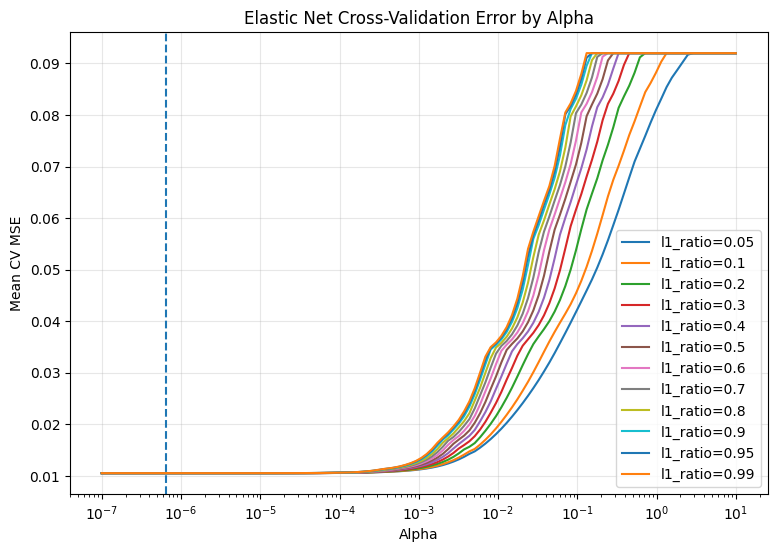

In [8]:
mean_mse = elastic_net.mse_path_.mean(axis=2)

plt.figure(figsize=(9, 6))
for i, l1 in enumerate(elastic_net.l1_ratio):
    plt.semilogx(elastic_net.alphas_, mean_mse[i], label=f"l1_ratio={l1}")

plt.axvline(elastic_net.alpha_, linestyle="--")
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("Elastic Net Cross-Validation Error by Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Predictions

The model predicts on the **log price scale**, because the target is `log_resale_price_real`.

Then predictions are exponentiated back to the original SGD scale to make the results easier to interpret.


In [9]:
y_pred_log = elastic_net.predict(X_test)

train_pred_log = elastic_net.predict(X_train)
smearing_factor = np.mean(np.exp(y_train - train_pred_log))

y_pred_actual = np.exp(y_pred_log) * smearing_factor

pred_df = pd.DataFrame({
    "actual_log": y_test,
    "predicted_log": y_pred_log,
    "actual_price": y_test_actual,
    "predicted_price": y_pred_actual
})

pred_df.head(10)

,actual_log,predicted_log,actual_price,predicted_price
39050,12.941217,12.905927,417156.61,4.048735e+05
90120,13.692717,13.695942,884446.38,8.921109e+05
82429,13.088883,12.987627,483537.14,4.393405e+05
86733,13.577806,13.557006,788435.46,7.763896e+05
75312,13.400348,13.422597,660232.82,6.787450e+05
121571,13.726330,13.735440,914680.60,9.280528e+05
115004,13.784938,13.684693,969889.59,8.821320e+05
64691,13.665677,13.837378,860851.31,1.027646e+06
78471,13.150367,13.150339,514199.77,5.169711e+05
92323,13.004160,12.888521,444257.58,3.978875e+05


## 10. Evaluation metrics

We report two sets of metrics:

### On log scale
This is the most direct comparison to the OLS model since OLS also used `log_resale_price_real` as the dependent variable.

### On original price scale
This is more intuitive in dollar terms, because RMSE and MAE are in SGD.
This is after converting predictions back from log



In [11]:
# Lin-Lin loss with w = 2
def linlin_loss(y_true, y_pred, w=2):
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, w * np.abs(errors), np.abs(errors)))

r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
linlin_log = linlin_loss(y_test, y_pred_log, w=2)

r2_actual = r2_score(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
linlin_actual = linlin_loss(y_test_actual, y_pred_actual, w=2)

metrics_df = pd.DataFrame({
    "scale": ["log_resale_price_real", "resale_price_real"],
    "R2": [r2_log, r2_actual],
    "RMSE": [rmse_log, rmse_actual],
    "LinLinLoss_w2": [linlin_log, linlin_actual]
})

print("===== ELASTIC NET RESULTS (MATCHED TO OLS SPEC) =====")
display(metrics_df)

===== ELASTIC NET RESULTS (MATCHED TO OLS SPEC) =====


,scale,R2,RMSE,LinLinLoss_w2
0,log_resale_price_real,0.884141,0.102933,0.118190
1,resale_price_real,0.872334,74204.240695,79990.803795


## 11. Coefficients

Elastic Net produces coefficients for each feature.

Because it includes regularisation:
- some coefficients may be shrunk strongly toward zero
- some may become exactly zero, especially when `l1_ratio` is close to 1

This is useful to explain that Elastic Net performs both:
- prediction
- variable selection / shrinkage


In [13]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": elastic_net.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

coef_df.head(20)

,feature,coefficient
15,flat_type_MULTI-GENERATION,1.240736
14,flat_type_EXECUTIVE,1.083276
13,flat_type_5 ROOM,0.819556
12,flat_type_4 ROOM,0.620956
34,town_SEMBAWANG,-0.325072
11,flat_type_3 ROOM,0.322748
30,town_MARINE PARADE,0.304254
35,town_SENGKANG,-0.286593
21,town_BUKIT TIMAH,0.277671
20,town_BUKIT PANJANG,-0.273665
